# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Balverdi Valentina 
- Alumno 2 : Prieto Tobias

In [ ]:
# =============================================================================
# PASO 1 — Carga de librerías
# =============================================================================
# Copiar esta celda como la primera celda de código en train.ipynb

import os
import sys
import glob
import random
import warnings
from pathlib import Path
from collections import defaultdict
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms



warnings.filterwarnings("ignore")


In [4]:

# ----- Configuración de dispositivo GPU -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# ----- Rutas del proyecto -----
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "dateset_propio"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "output"
LFW_DIR = PROJECT_ROOT / "data" / "lfw"

# Crear directorios si no existen
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LFW_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset propio:     {DATA_DIR}")
print(f"Modelos:            {MODELS_DIR}")
print(f"LFW:                {LFW_DIR}")

# ----- Semilla para reproducibilidad -----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\n✅ Librerías cargadas correctamente.")


Dispositivo: cuda
Raíz del proyecto: C:\Users\tobia\Desktop\ForkValen\tuia-face-recognition-app
Dataset propio:     C:\Users\tobia\Desktop\ForkValen\tuia-face-recognition-app\data\dateset_propio
Modelos:            C:\Users\tobia\Desktop\ForkValen\tuia-face-recognition-app\models
LFW:                C:\Users\tobia\Desktop\ForkValen\tuia-face-recognition-app\data\lfw

✅ Librerías cargadas correctamente.


In [7]:
# ----- Listar todas las identidades y sus imágenes -----
dataset_info = {}
for persona_dir in sorted(DATA_DIR.iterdir()): # iterdir permite iterar sobre directorios
    if persona_dir.is_dir():
        imgs = list(persona_dir.glob("*.jpeg")) + list(persona_dir.glob("*.jpg")) + list(persona_dir.glob("*.png")) # glob selecciona todos los archivos que coincidan con extension
        dataset_info[persona_dir.name] = imgs   # agrega al dict el nombre de la persona y sus imagenes

# Tabla resumen
print("=" * 50)
print("RESUMEN DEL DATASET PROPIO")
print("=" * 50)
summary_data = []
total = 0
for nombre, imgs in dataset_info.items():
    summary_data.append({"Persona": nombre, "Cantidad": len(imgs)})
    total += len(imgs)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print(f"\nTotal de imágenes: {total}")
print(f"Total de identidades: {len(dataset_info)}")



RESUMEN DEL DATASET PROPIO
Persona  Cantidad
ALCARAZ        20
  MESSI        20
  NADAL        20
   NATE        20
  NOVAK        20
 TOBIAS        20

Total de imágenes: 120
Total de identidades: 6


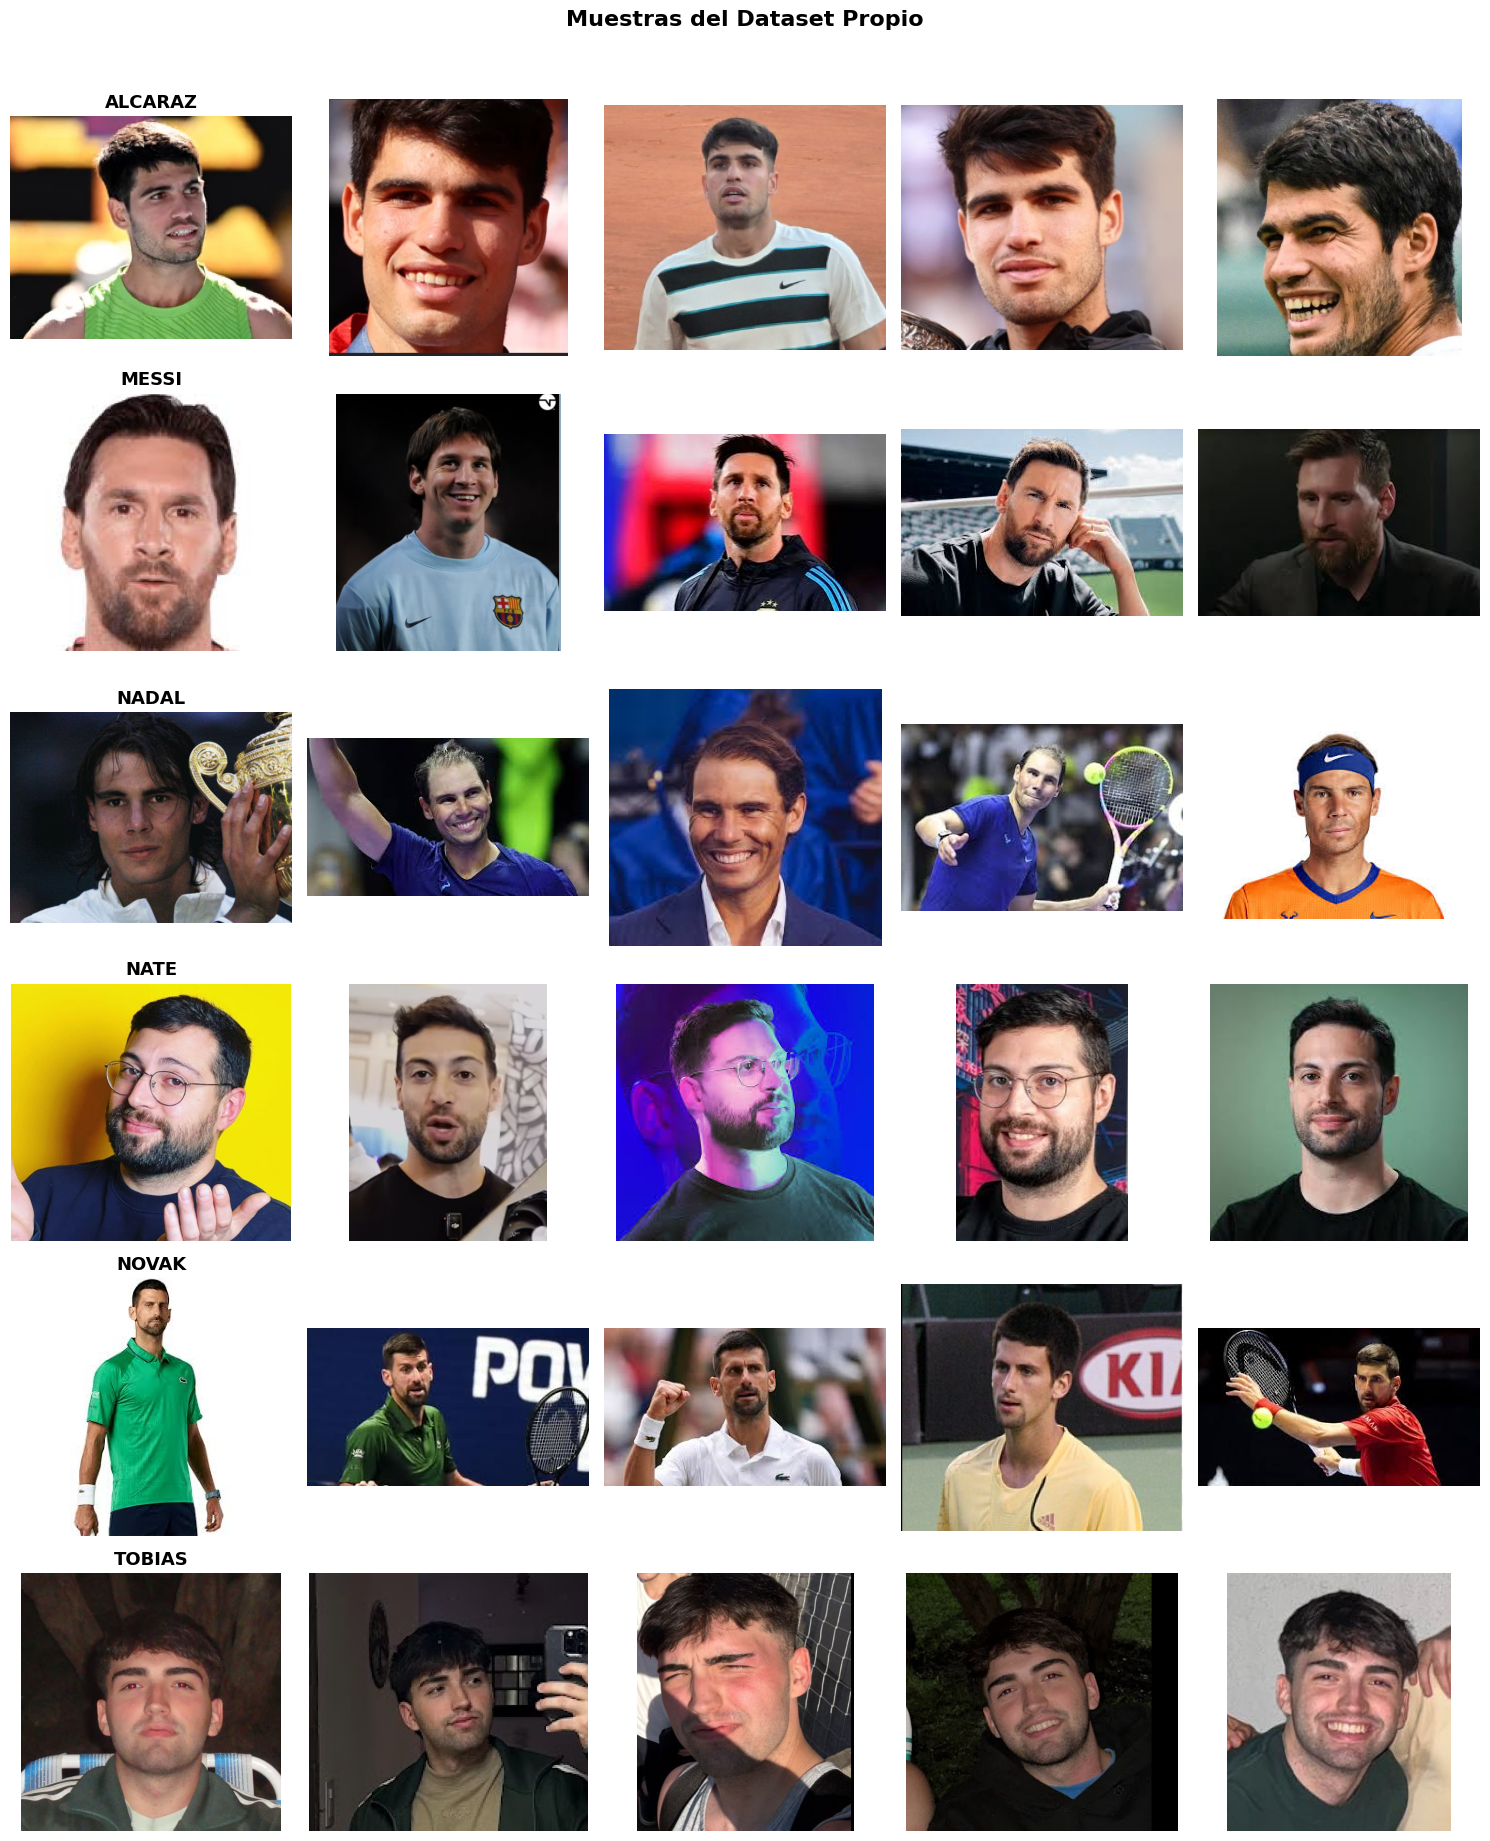

In [9]:

# ----- Visualización de muestras por persona -----
n_personas = len(dataset_info)
n_show = min(5, min(len(imgs) for imgs in dataset_info.values()))

fig, axes = plt.subplots(n_personas, n_show, figsize=(3 * n_show, 3 * n_personas))
if n_personas == 1:
    axes = [axes]

for row, (nombre, imgs) in enumerate(dataset_info.items()):
    sample_imgs = random.sample(imgs, n_show)
    for col, img_path in enumerate(sample_imgs):
        img = Image.open(img_path).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_title(nombre, fontsize=13, fontweight="bold")

plt.suptitle("Muestras del Dataset Propio", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


